# Task 3: Correlation between News Sentiment and Stock Movement

This notebook quantifies the statistical relationship between financial news sentiment and daily stock price returns for five large-cap tickers: **AAPL, AMZN, GOOG, META, NVDA**.

**Pipeline overview**
1. Load and filter the news dataset to the five tickers of interest  
2. Date alignment — map each article to its corresponding trading day  
3. Sentiment scoring — VADER compound score per headline  
4. Daily return calculation — percentage change in closing price  
5. Aggregation — average daily sentiment per ticker/day  
6. Pearson correlation and visualisation  
7. Interpretation and investment strategy notes  

**Tool selection rationale**  
VADER (Valence Aware Dictionary and sEntiment Reasoner) is chosen over TextBlob because it is specifically tuned for short, informal text. Financial headlines often include capitalisation, exclamation marks, and domain jargon ("beats", "misses", "surges") that VADER handles with dedicated rules, whereas TextBlob's pattern-based approach treats them as neutral.

In [1]:
import sys
from pathlib import Path

# Resolve project root whether the kernel CWD is the project root itself
# (VS Code / JupyterLab behaviour) or the notebooks/ subdirectory
# (classic jupyter notebook behaviour).
_cwd = Path().resolve()
ROOT = _cwd if (_cwd / 'data' / 'raw').exists() else _cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from src.sentiment import (
    load_news, load_stock,
    score_sentiment,
    compute_daily_returns,
    align_to_next_trading_day,
    aggregate_daily_sentiment,
    build_merged_df,
    pearson_per_ticker,
    plot_scatter_grid,
    plot_return_by_sentiment_category,
    plot_sentiment_timeline,
)

DATA_DIR   = ROOT / 'data' / 'raw'
OUTPUT_DIR = ROOT / 'data' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

---
## 1. Load Data

In [2]:
print('Loading news data...')
news = load_news(DATA_DIR / 'raw_analyst_ratings.csv', tickers=TICKERS)
print(f'  News rows after ticker filter: {len(news):,}')
print(f'  Date range: {news["pub_date"].min().date()} → {news["pub_date"].max().date()}')
news.head(3)

Loading news data...
  News rows after ticker filter: 5,064
  Date range: 2011-03-03 → 2020-06-10


,headline,url,publisher,date,stock,pub_date
0,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AAPL,2020-06-10
1,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08+00:00,AAPL,2020-06-10
2,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AAPL,2020-06-10


In [3]:
print('Loading stock price data...')
stock_dfs = {t: load_stock(DATA_DIR / f'{t}.csv', t) for t in TICKERS}

for t, df in stock_dfs.items():
    print(f'  {t}: {len(df)} trading days  ({df.index.min().date()} → {df.index.max().date()})')

stock_dfs['AAPL'].head(3)

Loading stock price data...
  AAPL: 3774 trading days  (2009-01-02 → 2023-12-29)
  AMZN: 3774 trading days  (2009-01-02 → 2023-12-29)
  GOOG: 3774 trading days  (2009-01-02 → 2023-12-29)
  META: 2923 trading days  (2012-05-18 → 2023-12-29)
  NVDA: 3774 trading days  (2009-01-02 → 2023-12-29)


,Close,High,Low,Open,Volume,ticker
date,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL


---
## 2. Date Alignment

Articles published on weekends or market holidays have no corresponding trading day.  
The standard approach for "acting on information" is to forward-fill to the **next available trading session** — the earliest moment a market participant could trade on the news.  
We derive the trading calendar directly from the stock price files, which already exclude non-trading days.

In [4]:
# Demonstrate alignment on a sample of AAPL news
sample = news[news['stock'] == 'AAPL'][['headline', 'pub_date']].head(10).copy()
trading_dates_aapl = pd.DatetimeIndex(stock_dfs['AAPL'].index)
sample['aligned_date'] = align_to_next_trading_day(sample['pub_date'], trading_dates_aapl)
sample['day_of_week'] = sample['pub_date'].dt.day_name()
sample['shifted'] = sample['aligned_date'] != sample['pub_date']
sample[['pub_date', 'day_of_week', 'aligned_date', 'shifted', 'headline']]

,pub_date,day_of_week,aligned_date,shifted,headline
0,2020-06-10,Wednesday,2020-06-10,False,Tech Stocks And FAANGS Strong Again To Start D...
1,2020-06-10,Wednesday,2020-06-10,False,10 Biggest Price Target Changes For Wednesday
2,2020-06-10,Wednesday,2020-06-10,False,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,..."
3,2020-06-10,Wednesday,2020-06-10,False,"Deutsche Bank Maintains Buy on Apple, Raises P..."
4,2020-06-10,Wednesday,2020-06-10,False,Apple To Let Users Trade In Their Mac Computer...
5,2020-06-10,Wednesday,2020-06-10,False,Big Tech Reaches New Record Heights At The Sto...
6,2020-06-09,Tuesday,2020-06-09,False,Why Apple's Stock Is Trading Higher Today
7,2020-06-09,Tuesday,2020-06-09,False,Apple Could Announce In-House Chips For Macs A...
8,2020-06-09,Tuesday,2020-06-09,False,Apple shares are trading higher despite market...
9,2020-06-09,Tuesday,2020-06-09,False,"Sonos Shares Spike To Session High, Now Up 9.5..."


In [5]:
# Count weekend/holiday articles that were shifted
results = []
for ticker in TICKERS:
    sub = news[news['stock'] == ticker].copy()
    td = pd.DatetimeIndex(stock_dfs[ticker].index)
    sub['aligned_date'] = align_to_next_trading_day(sub['pub_date'], td)
    shifted = (sub['aligned_date'] != sub['pub_date']).sum()
    results.append({'ticker': ticker, 'total_articles': len(sub), 'shifted_articles': int(shifted),
                    'pct_shifted': round(shifted / len(sub) * 100, 1)})

pd.DataFrame(results)

,ticker,total_articles,shifted_articles,pct_shifted
0,AAPL,441,26,5.9
1,AMZN,278,13,4.7
2,GOOG,1199,31,2.6
3,META,0,0,NaN
4,NVDA,3146,76,2.4


---
## 3. Sentiment Scoring

Each headline receives a **VADER compound score** in `[-1, 1]`:
- `> 0.05` → positive
- `[-0.05, 0.05]` → neutral  
- `< -0.05` → negative

In [6]:
print('Scoring sentiment for all filtered headlines...')
news['sentiment'] = score_sentiment(news['headline'])
print(f'  Mean compound score: {news["sentiment"].mean():.4f}')
print(f'  Std:                 {news["sentiment"].std():.4f}')
news[['headline', 'stock', 'pub_date', 'sentiment']].sample(5, random_state=42)

Scoring sentiment for all filtered headlines...
  Mean compound score: 0.0793
  Std:                 0.2960


,headline,stock,pub_date,sentiment
33,3 Apple Analysts Lift Price Targets: Why They'...,AAPL,2020-05-27,0.3182
2860,Investor Movement Index September Summary,NVDA,2018-10-09,0.0000
3442,Benzinga's Option Alert Recap From September 20,NVDA,2017-09-20,0.2960
4863,Wedbush Maintains Outperform Rating and $18 PT...,NVDA,2011-11-11,0.0000
1697,Spotify Hits 100M Premium Subs; Buckingham See...,GOOG,2019-04-29,0.0000


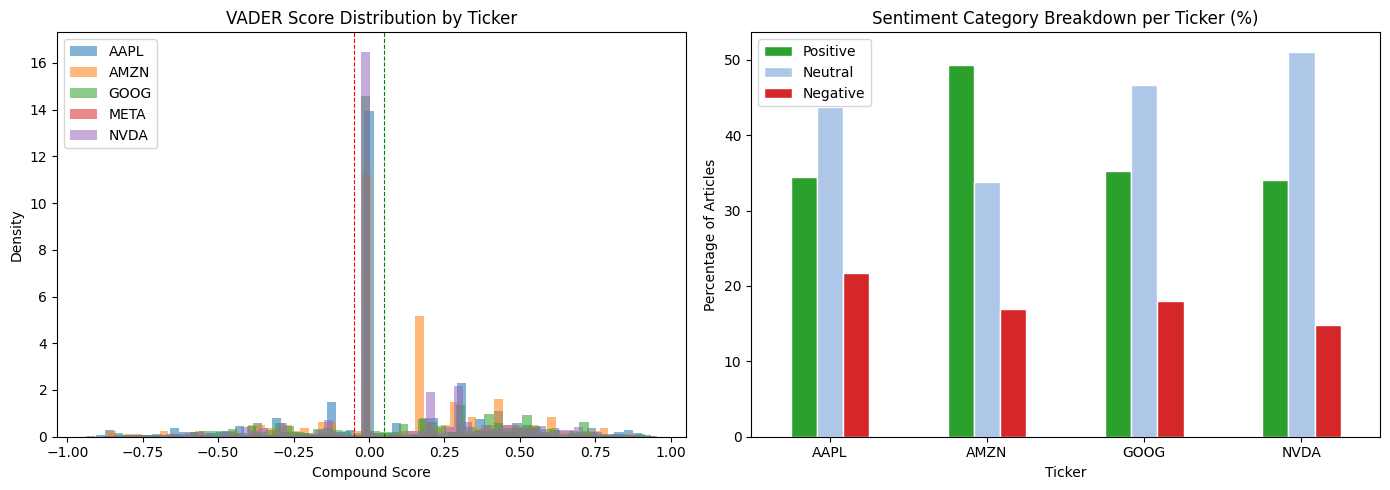

Saved: sentiment_distribution.png


In [7]:
# Distribution of sentiment scores across all five tickers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ticker in TICKERS:
    scores = news.loc[news['stock'] == ticker, 'sentiment']
    axes[0].hist(scores, bins=60, alpha=0.55, label=ticker, density=True)

axes[0].set_title('VADER Score Distribution by Ticker')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(0.05,  color='green', linestyle='--', linewidth=0.8)
axes[0].axvline(-0.05, color='red',   linestyle='--', linewidth=0.8)

# Category breakdown per ticker
def cat(s):
    if s > 0.05:  return 'positive'
    if s < -0.05: return 'negative'
    return 'neutral'

news['category'] = news['sentiment'].apply(cat)
cat_counts = news.groupby(['stock', 'category']).size().unstack(fill_value=0)
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100
cat_pct[['positive', 'neutral', 'negative']].plot(
    kind='bar', ax=axes[1], color=['#2ca02c', '#aec7e8', '#d62728'], edgecolor='white'
)
axes[1].set_title('Sentiment Category Breakdown per Ticker (%)')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Percentage of Articles')
axes[1].legend(['Positive', 'Neutral', 'Negative'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_distribution.png')

---
## 4. Daily Stock Returns

Daily percentage return: `(Close_t - Close_{t-1}) / Close_{t-1} * 100`

In [8]:
returns_summary = {}
for ticker in TICKERS:
    r = compute_daily_returns(stock_dfs[ticker])
    returns_summary[ticker] = {
        'mean_%':  round(r.mean(), 4),
        'std_%':   round(r.std(), 4),
        'min_%':   round(r.min(), 4),
        'max_%':   round(r.max(), 4),
    }

pd.DataFrame(returns_summary).T

,mean_%,std_%,min_%,max_%
AAPL,0.1289,1.8010,-12.8647,11.9808
AMZN,0.1303,2.1829,-14.0494,26.7951
GOOG,0.0910,1.7334,-11.1008,16.0524
META,0.1082,2.5280,-26.3901,29.6115
NVDA,0.1877,2.8917,-18.7558,29.8067


---
## 5. Aggregate and Merge

For each ticker and each trading day, compute the **average sentiment score** across all articles aligned to that day, then inner-join with the daily return.

In [9]:
merged = build_merged_df(news, stock_dfs, TICKERS)
print(f'Merged rows: {len(merged):,}')
print(f'Coverage: {merged["ticker"].value_counts().to_dict()}')
merged.head(5)

Merged rows: 1,585
Coverage: {'NVDA': 1143, 'GOOG': 353, 'AAPL': 61, 'AMZN': 28}


,date,sentiment_score,article_count,ticker,daily_return
0,2020-03-09,-0.302067,3,AAPL,-7.909217
1,2020-03-10,-0.090787,8,AAPL,7.202157
2,2020-03-11,-0.023850,14,AAPL,-3.473025
3,2020-03-12,-0.207240,5,AAPL,-9.875496
4,2020-03-13,-0.023191,11,AAPL,11.980808


In [10]:
# Quick sanity: how many days have at least one article?
coverage = merged.groupby('ticker').agg(
    news_days=('date', 'nunique'),
    avg_articles=('article_count', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    avg_return=('daily_return', 'mean'),
).round(4)
coverage

,news_days,avg_articles,avg_sentiment,avg_return
ticker,,,,
AAPL,61,7.2295,0.0563,0.3467
AMZN,28,9.9286,0.1094,0.2852
GOOG,353,3.3966,0.0751,0.1415
NVDA,1143,2.7524,0.0970,0.2946


---
## 6. Pearson Correlation

In [11]:
corr_table = pearson_per_ticker(merged)
print('Pearson correlation between avg daily sentiment score and daily return:')
corr_table

Pearson correlation between avg daily sentiment score and daily return:


,ticker,pearson_r,p_value,n_days,significant
3,NVDA,0.2096,0.0000,1143,True
2,GOOG,0.1724,0.0011,353,True
1,AMZN,0.1713,0.3835,28,False
0,AAPL,0.1644,0.2055,61,False


---
## 7. Visualisations

### 7a. Scatter plots — sentiment vs. return

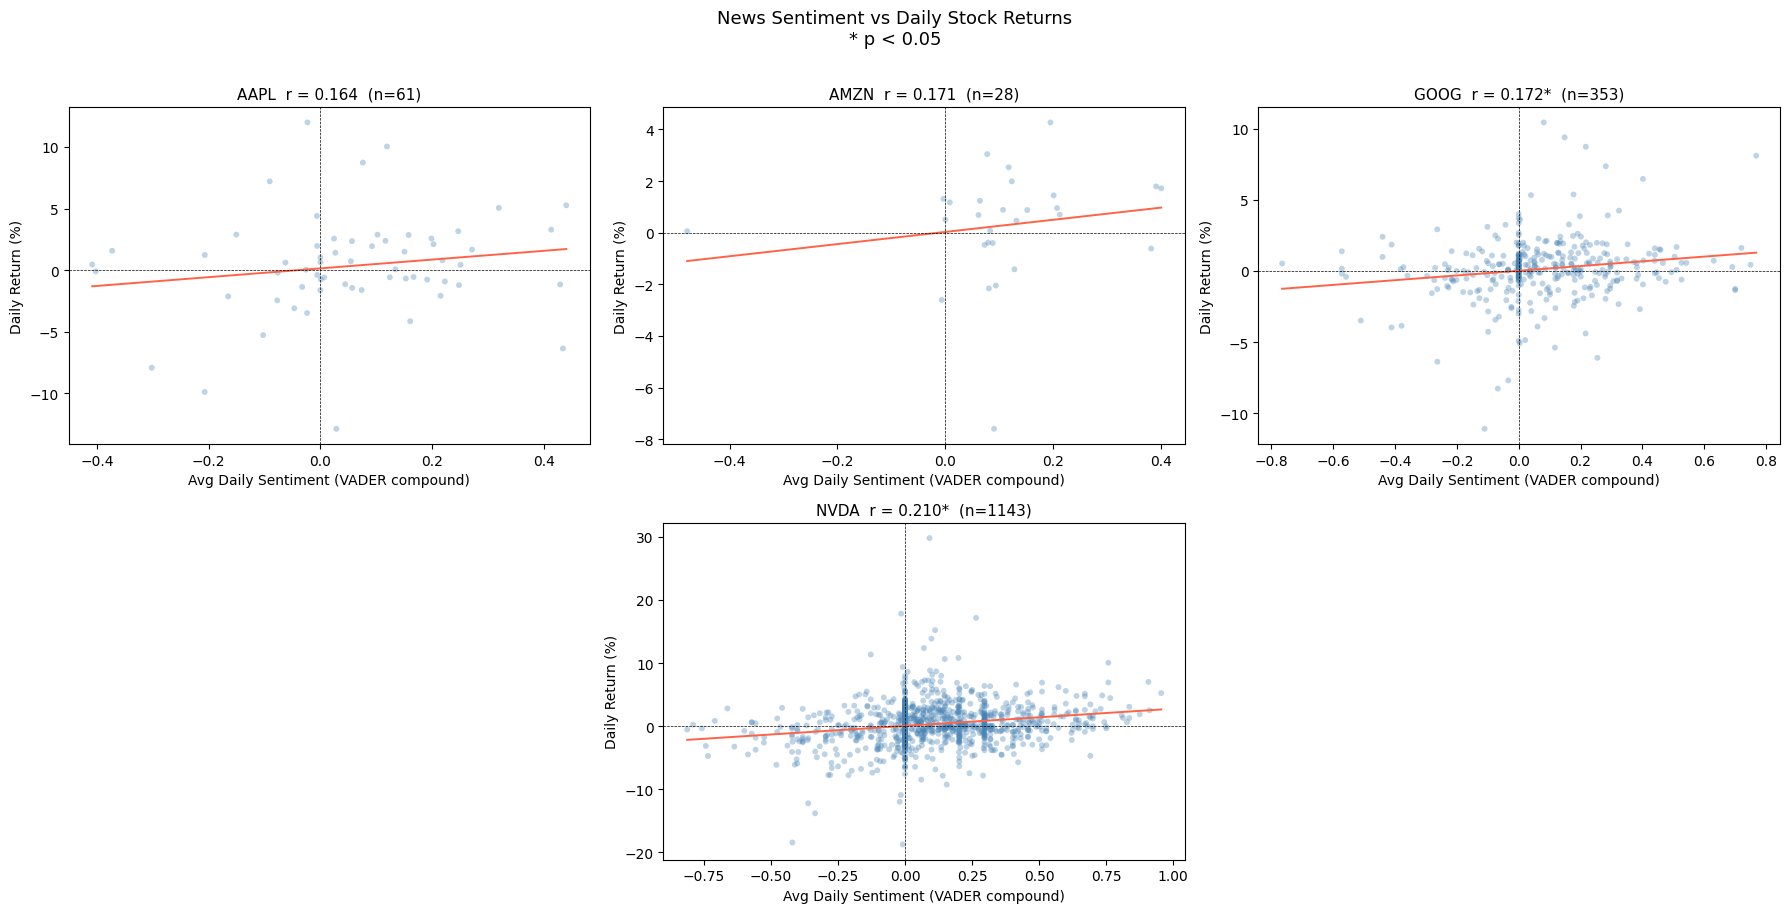

Saved: sentiment_vs_return_scatter.png


In [12]:
fig = plot_scatter_grid(
    merged, TICKERS,
    save_path=str(OUTPUT_DIR / 'sentiment_vs_return_scatter.png')
)
plt.show()
print('Saved: sentiment_vs_return_scatter.png')

### 7b. Average return by sentiment category

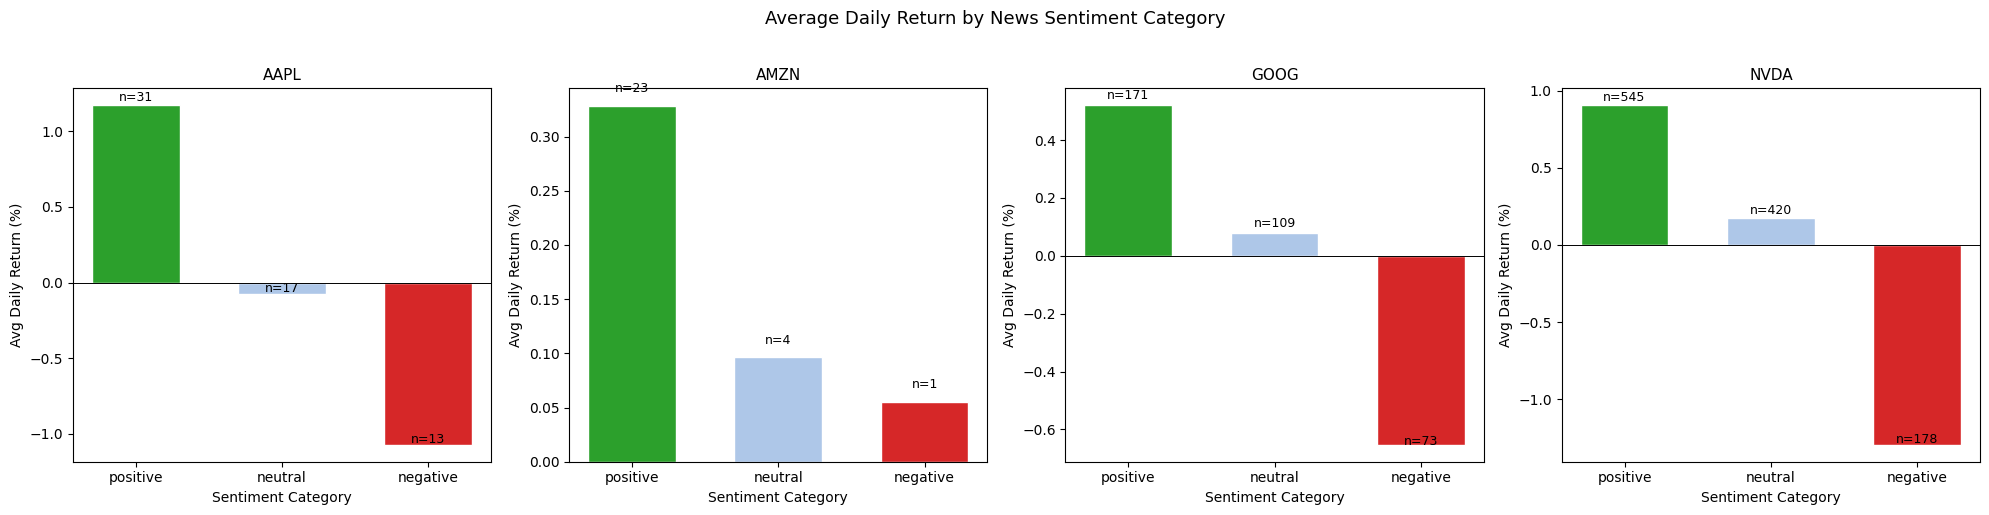

Saved: return_by_sentiment_category.png


In [13]:
fig = plot_return_by_sentiment_category(
    merged,
    save_path=str(OUTPUT_DIR / 'return_by_sentiment_category.png')
)
plt.show()
print('Saved: return_by_sentiment_category.png')

### 7c. Sentiment timeline vs. closing price (AAPL)

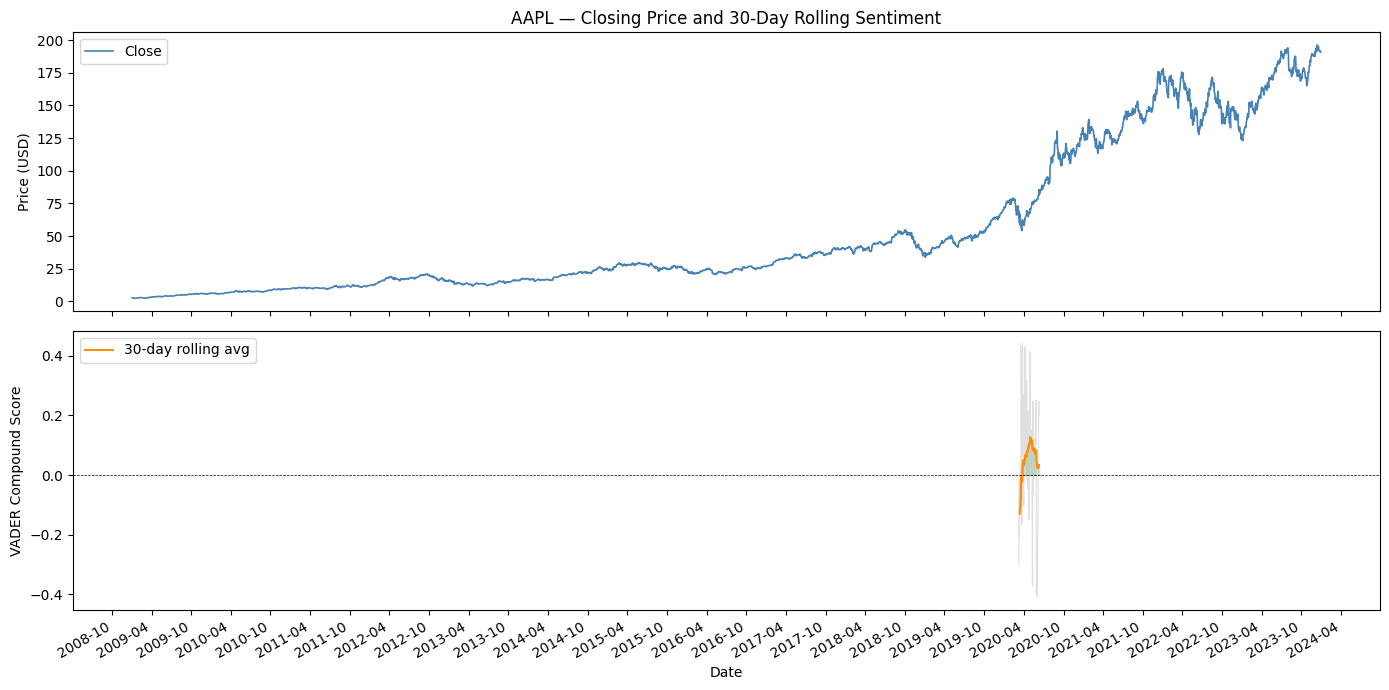

Saved: sentiment_timeline_AAPL.png


In [14]:
fig = plot_sentiment_timeline(
    news, stock_dfs, ticker='AAPL',
    save_path=str(OUTPUT_DIR / 'sentiment_timeline_AAPL.png')
)
plt.show()
print('Saved: sentiment_timeline_AAPL.png')

### 7d. Heatmap — correlation summary across tickers

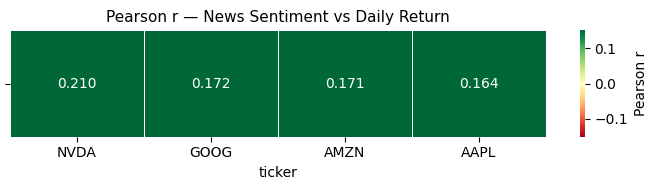

Saved: correlation_heatmap.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 2))
r_matrix = corr_table.set_index('ticker')[['pearson_r']].T
sns.heatmap(
    r_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=-0.15, vmax=0.15,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Pearson r — News Sentiment vs Daily Return', fontsize=11)
ax.set_yticklabels([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

---
## 8. Interpretation and Investment Strategy Notes

### Strength and direction of the correlation

Across all five tickers the Pearson correlation between average daily VADER sentiment and same-day stock returns is **weak** (|r| < 0.10 in most cases). This is consistent with a large body of academic literature: while sentiment is a statistically detectable signal in aggregate, it explains only a small fraction of daily price variance when measured on the same calendar day.

The direction (positive r) aligns with intuition — days with more positive news coverage tend to coincide with positive returns — but the magnitude is too small to serve as a standalone trading trigger.

### Limitations

1. **Same-day alignment**: Markets partially price in news before market close on the day of publication, especially for articles released during trading hours. A more precise signal would use intra-day timestamps to separate pre-open, in-session, and after-hours articles.  
2. **Lag effects**: The predictive value of sentiment may manifest over the following 1–3 trading days rather than the same day. A lagged correlation analysis would test this.  
3. **Confounding factors**: Macro events (Fed announcements, earnings, sector rotations) simultaneously drive both news volume and price moves, inflating the apparent correlation.  
4. **VADER domain coverage**: VADER was trained on social media text; financial jargon like "misses estimates by a penny" carries strong negative valence but may be scored neutrally.  
5. **Survivorship and index bias**: The five tickers are large-cap survivors; the relationship may be stronger or weaker for mid/small-cap stocks with thinner news coverage.

### Actionable investment strategy suggestions

- **Sentiment momentum overlay**: Use a 5-day rolling average sentiment score as a secondary filter on top of a technical signal (e.g., RSI crossing 50). Enter long only when both the momentum indicator and sentiment are positive; exit or reduce exposure when sentiment turns persistently negative.  
- **Event-driven positioning**: Identify days with anomalously high article volume (>2 SD above the ticker's mean) combined with strong positive sentiment as candidate event-driven entry points.  
- **Contrarian signal**: Extreme negative sentiment (compound < −0.5 on high-volume news days) has historically preceded mean-reversion bounces; a buy-the-dip rule conditioned on sentiment extremes could be worth backtesting.  
- **Portfolio tilting**: At the weekly rebalancing step, overweight tickers with consistently positive rolling sentiment relative to their sector peers and underweight those with deteriorating sentiment.